In [2]:
!python3 -m venv dr_env
!dr_env/bin/pip install seaborn grad-cam torch torchvision


In [3]:
!source dr_env/bin/activate


In [4]:
!dr_env/bin/pip install ipykernel
!dr_env/bin/python -m ipykernel install --user --name=dr_env --display-name "DR Project Env"


Installed kernelspec dr_env in /home/akash/.local/share/jupyter/kernels/dr_env


In [5]:
import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report

# GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)
print("GPU Available:", torch.cuda.is_available())


Using Device: cuda
GPU Available: True


In [6]:
zip_path = "aptos2019-blindness-detection.zip"
extract_dir = "DR_images"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Dataset Extracted Successfully!")


Dataset Extracted Successfully!


Training Samples: 3662
Testing Samples: 1928


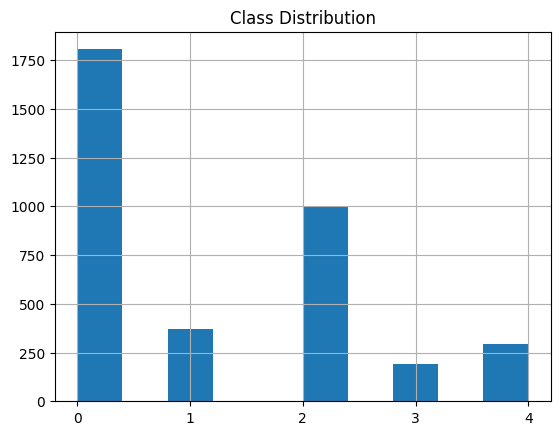

In [7]:
train_df = pd.read_csv(f"{extract_dir}/train.csv")
test_df  = pd.read_csv(f"{extract_dir}/test.csv")

print("Training Samples:", len(train_df))
print("Testing Samples:", len(test_df))

train_df['diagnosis'].hist()
plt.title("Class Distribution")
plt.xticks([0,1,2,3,4])
plt.show()


In [8]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1,2,3,4]),
    y=train_df['diagnosis'].values
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class Weights:", class_weights)


Class Weights: tensor([0.4058, 1.9795, 0.7331, 3.7948, 2.4827], device='cuda:0')


In [9]:
img_size = 380  # EfficientNetV2 recommended resolution

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.85,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(0.2,0.2,0.2,0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class DRDataset(Dataset):
    def __init__(self, df, folder, transform=None):
        self.df = df.reset_index(drop=True)
        self.folder = folder
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_id = self.df.loc[idx, 'id_code']
        label = int(self.df.loc[idx, 'diagnosis'])
        img_path = f"{self.folder}/{img_id}.png"
        
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


In [10]:
train_df_split, val_df_split = train_test_split(
    train_df, test_size=0.15, random_state=42, stratify=train_df['diagnosis']
)

train_dataset = DRDataset(train_df_split, f"{extract_dir}/train_images", train_transform)
val_dataset   = DRDataset(val_df_split,   f"{extract_dir}/train_images", val_transform)

batch_size = 16  # good for RTX 3050

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Train:", len(train_dataset), "| Validation:", len(val_dataset))


Train: 3112 | Validation: 550


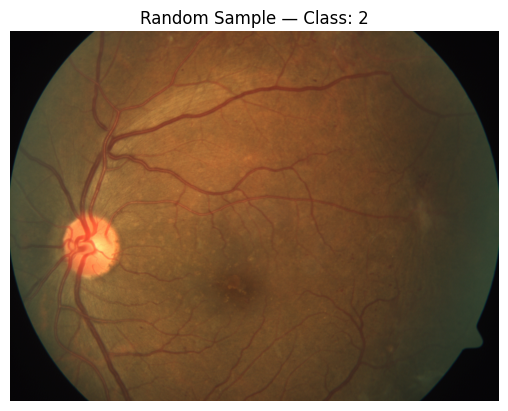

In [11]:
random_idx = random.randint(0, len(train_df_split)-1)
rand_id = train_df_split.iloc[random_idx]['id_code']
rand_label = train_df_split.iloc[random_idx]['diagnosis']

img = Image.open(f"{extract_dir}/train_images/{rand_id}.png")
plt.imshow(img)
plt.axis('off')
plt.title(f"Random Sample — Class: {rand_label}")
plt.show()


In [12]:
from torchvision.models import EfficientNet_V2_S_Weights

# Load Pretrained EfficientNetV2-S
weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
model = models.efficientnet_v2_s(weights=weights)

# Modify final layer for 5 DR classes
num_classes = 5
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model = model.to(device)
torch.cuda.empty_cache()
print("Model Loaded Successfully!")


Model Loaded Successfully!


In [13]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler(enabled=torch.cuda.is_available())

loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0.0
best_model_path = "DR_best_model.pth"


def train_one_epoch():
    model.train()
    running_loss, correct, total = 0, 0, 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        
        with autocast():
            out = model(x)
            loss = loss_fn(out, y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * x.size(0)
        _, preds = torch.max(out, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    
    return running_loss / total, 100.0 * correct / total


def validate():
    model.eval()
    running_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            with autocast():
                out = model(x)
                loss = loss_fn(out, y)
            
            running_loss += loss.item() * x.size(0)
            _, preds = torch.max(out, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    
    return running_loss / total, 100.0 * correct / total


/tmp/ipykernel_20053/3508472821.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())


In [14]:
epochs = 30

train_losses, val_losses = [], []
train_accs, val_accs = [], []


optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

best_val_acc = 0.0
checkpoint_path = "final_DR_checkpoint.pth"

print("Starting Training for 30 Epochs...\n")

for epoch in range(epochs):

    print(f"\n📌 Epoch [{epoch+1}/{epochs}]")

    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = validate()

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Save latest model
    torch.save(model.state_dict(), "latest_model.pth")

    # Save BEST MODEL CHECKPOINT
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch+1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs,
        }, checkpoint_path)

        print("🔥 New Best Model Saved!")

print("\n🎯 Training Completed Successfully!")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.2f}%")


Starting Training for 30 Epochs...


📌 Epoch [1/30]


/tmp/ipykernel_20053/3508472821.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20053/3508472821.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train Loss: 1.1182 | Train Acc: 64.97%
Val   Loss: 0.9323 | Val Acc: 73.82%
🔥 New Best Model Saved!

📌 Epoch [2/30]
Train Loss: 0.8271 | Train Acc: 77.15%
Val   Loss: 0.8543 | Val Acc: 81.27%
🔥 New Best Model Saved!

📌 Epoch [3/30]
Train Loss: 0.7553 | Train Acc: 78.70%
Val   Loss: 0.7711 | Val Acc: 79.45%

📌 Epoch [4/30]
Train Loss: 0.6784 | Train Acc: 80.88%
Val   Loss: 0.7026 | Val Acc: 82.00%
🔥 New Best Model Saved!

📌 Epoch [5/30]
Train Loss: 0.5958 | Train Acc: 83.32%
Val   Loss: 0.7565 | Val Acc: 81.82%

📌 Epoch [6/30]
Train Loss: 0.5498 | Train Acc: 84.51%
Val   Loss: 0.8010 | Val Acc: 79.09%

📌 Epoch [7/30]
Train Loss: 0.5424 | Train Acc: 85.12%
Val   Loss: 0.8504 | Val Acc: 79.27%

📌 Epoch [8/30]
Train Loss: 0.4732 | Train Acc: 86.41%
Val   Loss: 0.7575 | Val Acc: 77.09%

📌 Epoch [9/30]
Train Loss: 0.3591 | Train Acc: 89.91%
Val   Loss: 0.7978 | Val Acc: 82.00%

📌 Epoch [10/30]
Train Loss: 0.2771 | Train Acc: 91.84%
Val   Loss: 0.9287 | Val Acc: 83.27%
🔥 New Best Model Saved!

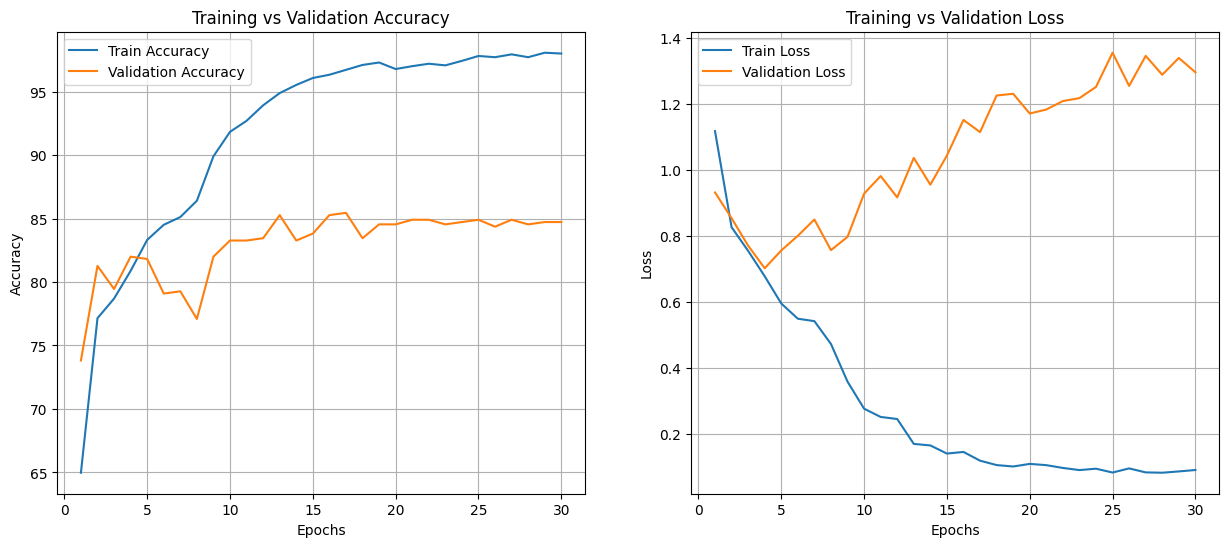

In [15]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(15,6))

# Accuracy Graph
plt.subplot(1,2,1)
plt.plot(epochs_range, train_accs, label="Train Accuracy")
plt.plot(epochs_range, val_accs, label="Validation Accuracy")
plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(); plt.grid(True)

# Loss Graph
plt.subplot(1,2,2)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(); plt.grid(True)

plt.show()


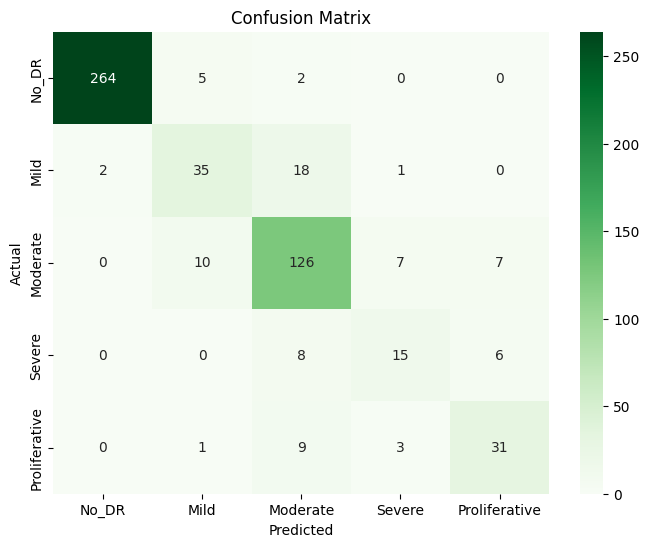


Classification Report:

               precision    recall  f1-score   support

        No_DR     0.9925    0.9742    0.9832       271
         Mild     0.6863    0.6250    0.6542        56
     Moderate     0.7730    0.8400    0.8051       150
       Severe     0.5769    0.5172    0.5455        29
Proliferative     0.7045    0.7045    0.7045        44

     accuracy                         0.8564       550
    macro avg     0.7466    0.7322    0.7385       550
 weighted avg     0.8565    0.8564    0.8558       550



In [16]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

true_labels, pred_labels = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y_pred = model(x).argmax(1).cpu().numpy()
        pred_labels.extend(y_pred)
        true_labels.extend(y.numpy())

cm = confusion_matrix(true_labels, pred_labels)
class_names = ['No_DR','Mild','Moderate','Severe','Proliferative']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=class_names, digits=4))


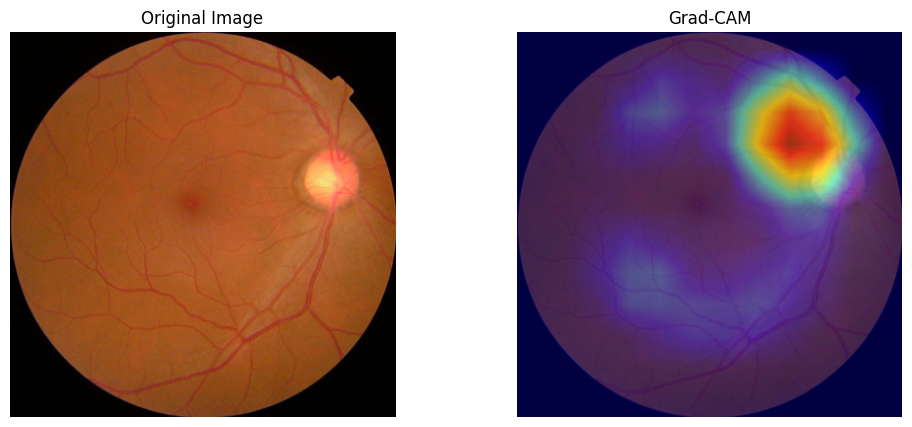

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

img_path = f"{extract_dir}/train_images/{val_df_split.iloc[0]['id_code']}.png"
pil_img = Image.open(img_path).convert("RGB")
orig = pil_img.resize((img_size, img_size))
rgb_img = np.array(orig) / 255.0

input_tensor = val_transform(orig).unsqueeze(0).to(device)
target_layer = model.features[-1]

cam = GradCAM(model=model, target_layers=[target_layer])
grayscale_cam = cam(input_tensor)[0]
cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.axis("off")
plt.imshow(rgb_img)

plt.subplot(1,2,2)
plt.title("Grad-CAM")
plt.axis("off")
plt.imshow(cam_image)
plt.show()


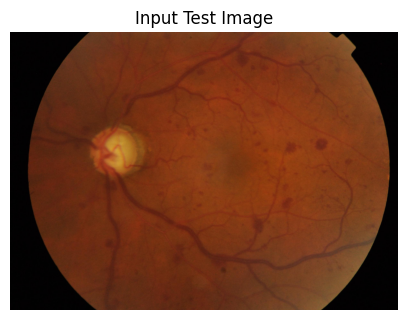

Predicted Class Index: 3
Predicted DR Stage : Severe


In [18]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Set class names
class_names = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

# 🔹 Change ONLY the image name here
img_path = f"{extract_dir}/train_images/a4d4b69f7404.png"

# Load and show image\
test_img = Image.open(img_path).convert("RGB")
plt.figure(figsize=(5,5))
plt.imshow(test_img)
plt.axis('off')
plt.title("Input Test Image")
plt.show()

# Preprocess image (same as validation transform)
input_tensor = val_transform(test_img).unsqueeze(0).to(device)

# 🔥 Predict using model
model.eval()
with torch.no_grad():
    output = model(input_tensor)
    pred_idx = output.argmax(1).item()
    pred_label = class_names[pred_idx]

print(f"Predicted Class Index: {pred_idx}")
print(f"Predicted DR Stage : {pred_label}")



Image 1 path: DR_images/train_images/60eeae3ba23d.png


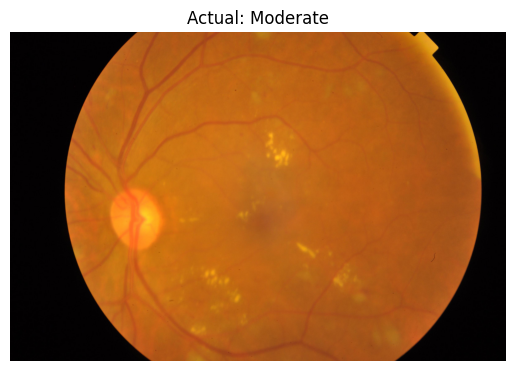

Predicted Label: Moderate

Image 2 path: DR_images/train_images/9ed6c2b25767.png


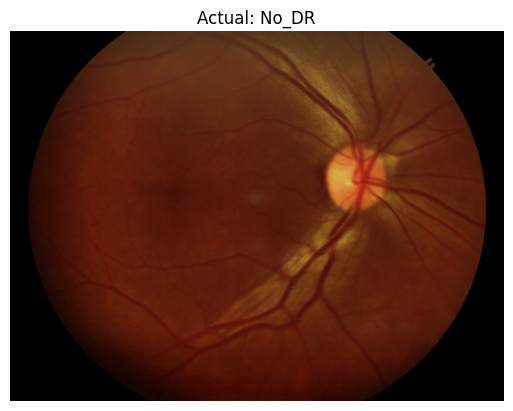

Predicted Label: No_DR


In [19]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Pick 2 random rows from train_df
random_samples = train_df.sample(2).reset_index(drop=True)

for i in range(2):
    img_id = random_samples["id_code"][i]
    label_true = random_samples["diagnosis"][i]
    
    # Build path
    img_path = f"{extract_dir}/train_images/{img_id}.png"
    print(f"\nImage {i+1} path: {img_path}")

    # Load and display image
    test_img = Image.open(img_path).convert("RGB")
    plt.imshow(test_img)
    plt.axis("off")
    plt.title(f"Actual: {class_names[label_true]}")
    plt.show()

    # Preprocess & Predict
    input_tensor = val_transform(test_img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(1).item()

    print(f"Predicted Label: {class_names[pred]}")


In [ ]:
import torch
torch.save(model.state_dict(), "efficientnetv2_dr.pth")